In [363]:
import glob
import fitsio
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression


In [364]:
systematics_list = ['H_Alpha', 'Stellar_Density_AllWISE', 'CSFD', 'PSFDEPTH_Z','PSFDEPTH_G','PSFDEPTH_R','PSFSIZE_G','PSFSIZE_R','PSFSIZE_Z','H_Alpha_Good']

In [365]:
path = '/user/animesh.sah/DESI_PECVEL/notebooks/imaging_systematics_maps/data/'
mask =hp.read_map(f'{path}/full_mask_nside_64_for_systmatics_20M.fits')
randoms_counts = hp.read_map(f'{path}/full_counts_randoms_nside_64.fits')

In [344]:
systematics_maps = {}
for sys_name in systematics_list:
    sys_map = hp.read_map(f'{path}/full_{sys_name}_nside_64.fits')
    systematics_maps[sys_name] = sys_map

In [370]:
def points_to_map(ra_deg, dec_deg, nside, weights=None):
    theta = np.radians(90.0 - dec_deg)  
    phi   = np.radians(ra_deg)
    ipix  = hp.ang2pix(nside, theta, phi, nest=False)
    npix  = hp.nside2npix(nside)
    if weights is None:
        weights = np.ones_like(ipix, dtype=np.float64)
    m = np.bincount(ipix, weights=weights, minlength=npix).astype(np.float64)
    return m
data = Table(fitsio.FITS('../table_match_final.fits')[1].read())
data = points_to_map(data['RA'], data['DEC'], nside=64)


In [371]:
max_count = randoms_counts[mask==1].max()
normalized_counts = randoms_counts / max_count
randoms_counts_subtracted =np.where(normalized_counts>0.25, randoms_counts, 0)

num_outside = len(normalized_counts[mask==1][normalized_counts[mask==1]<0.25])
print(f'Number of pixels outside 0.25: {num_outside}, out of {len(normalized_counts[mask==1])} total pixels')

data_counts_subtracted = np.where(normalized_counts>0.25, data, 0)



Number of pixels outside 0.25: 446, out of 21344 total pixels


In [387]:
def plot_systematic_relation(ngal, nran, features, num_bins=50, ax=None, **kwargs):
    """
    Plot the relationship between a systematic feature and galaxy density.

    Parameters
    ----------
    ngal : array-like
        Galaxy counts per pixel
    nran : array-like
        Random counts (weights) per pixel
    features : array-like
        Feature values (e.g., E(B-V), seeing, etc.)
    num_bins : int, optional
        Number of bins for equal-population binning (default: 50)
    ax : matplotlib.axes.Axes, optional
        Axes to plot on. If None, creates new figure.
    **kwargs : dict
        Additional keyword arguments passed to plt.plot()

    Returns
    -------
    bin_centers : array
        Center values of each bin
    normed_vals : array
        Normalized galaxy density in each bin
    """
    # Use numpy's percentile for equal-population binning
    bin_edges = np.nanpercentile(features, np.linspace(0, 100, num_bins+1))

    # Compute histograms
    rands, _ = np.histogram(features, bins=bin_edges, weights=nran)
    data, _ = np.histogram(features, bins=bin_edges, weights=ngal)

    # Compute normalized values
    norm_factor = rands.sum() / data.sum()
    normed_vals = (data / rands) * norm_factor

    # Bin centers
    bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2.0

    # Plot
    if ax is None:
        plt.figure()
        ax = plt.gca()

    ax.plot(bin_centers[:-1], normed_vals[:-1], 'k-', alpha=0.5, **kwargs)
    ax.plot(bin_centers[:-1], normed_vals[:-1], 'k.', **kwargs)

    ax.axhline(y=1.0, color='k', linestyle=':', alpha=0.5)
    ax.grid(linestyle='--', alpha=0.3)

    return bin_centers, normed_vals

In [388]:
ngal = data_counts_subtracted[mask==1]
nran = randoms_counts_subtracted[mask==1]

/tmp/ipykernel_1004543/453712755.py:36: RuntimeWarning: invalid value encountered in divide
  normed_vals = (data / rands) * norm_factor


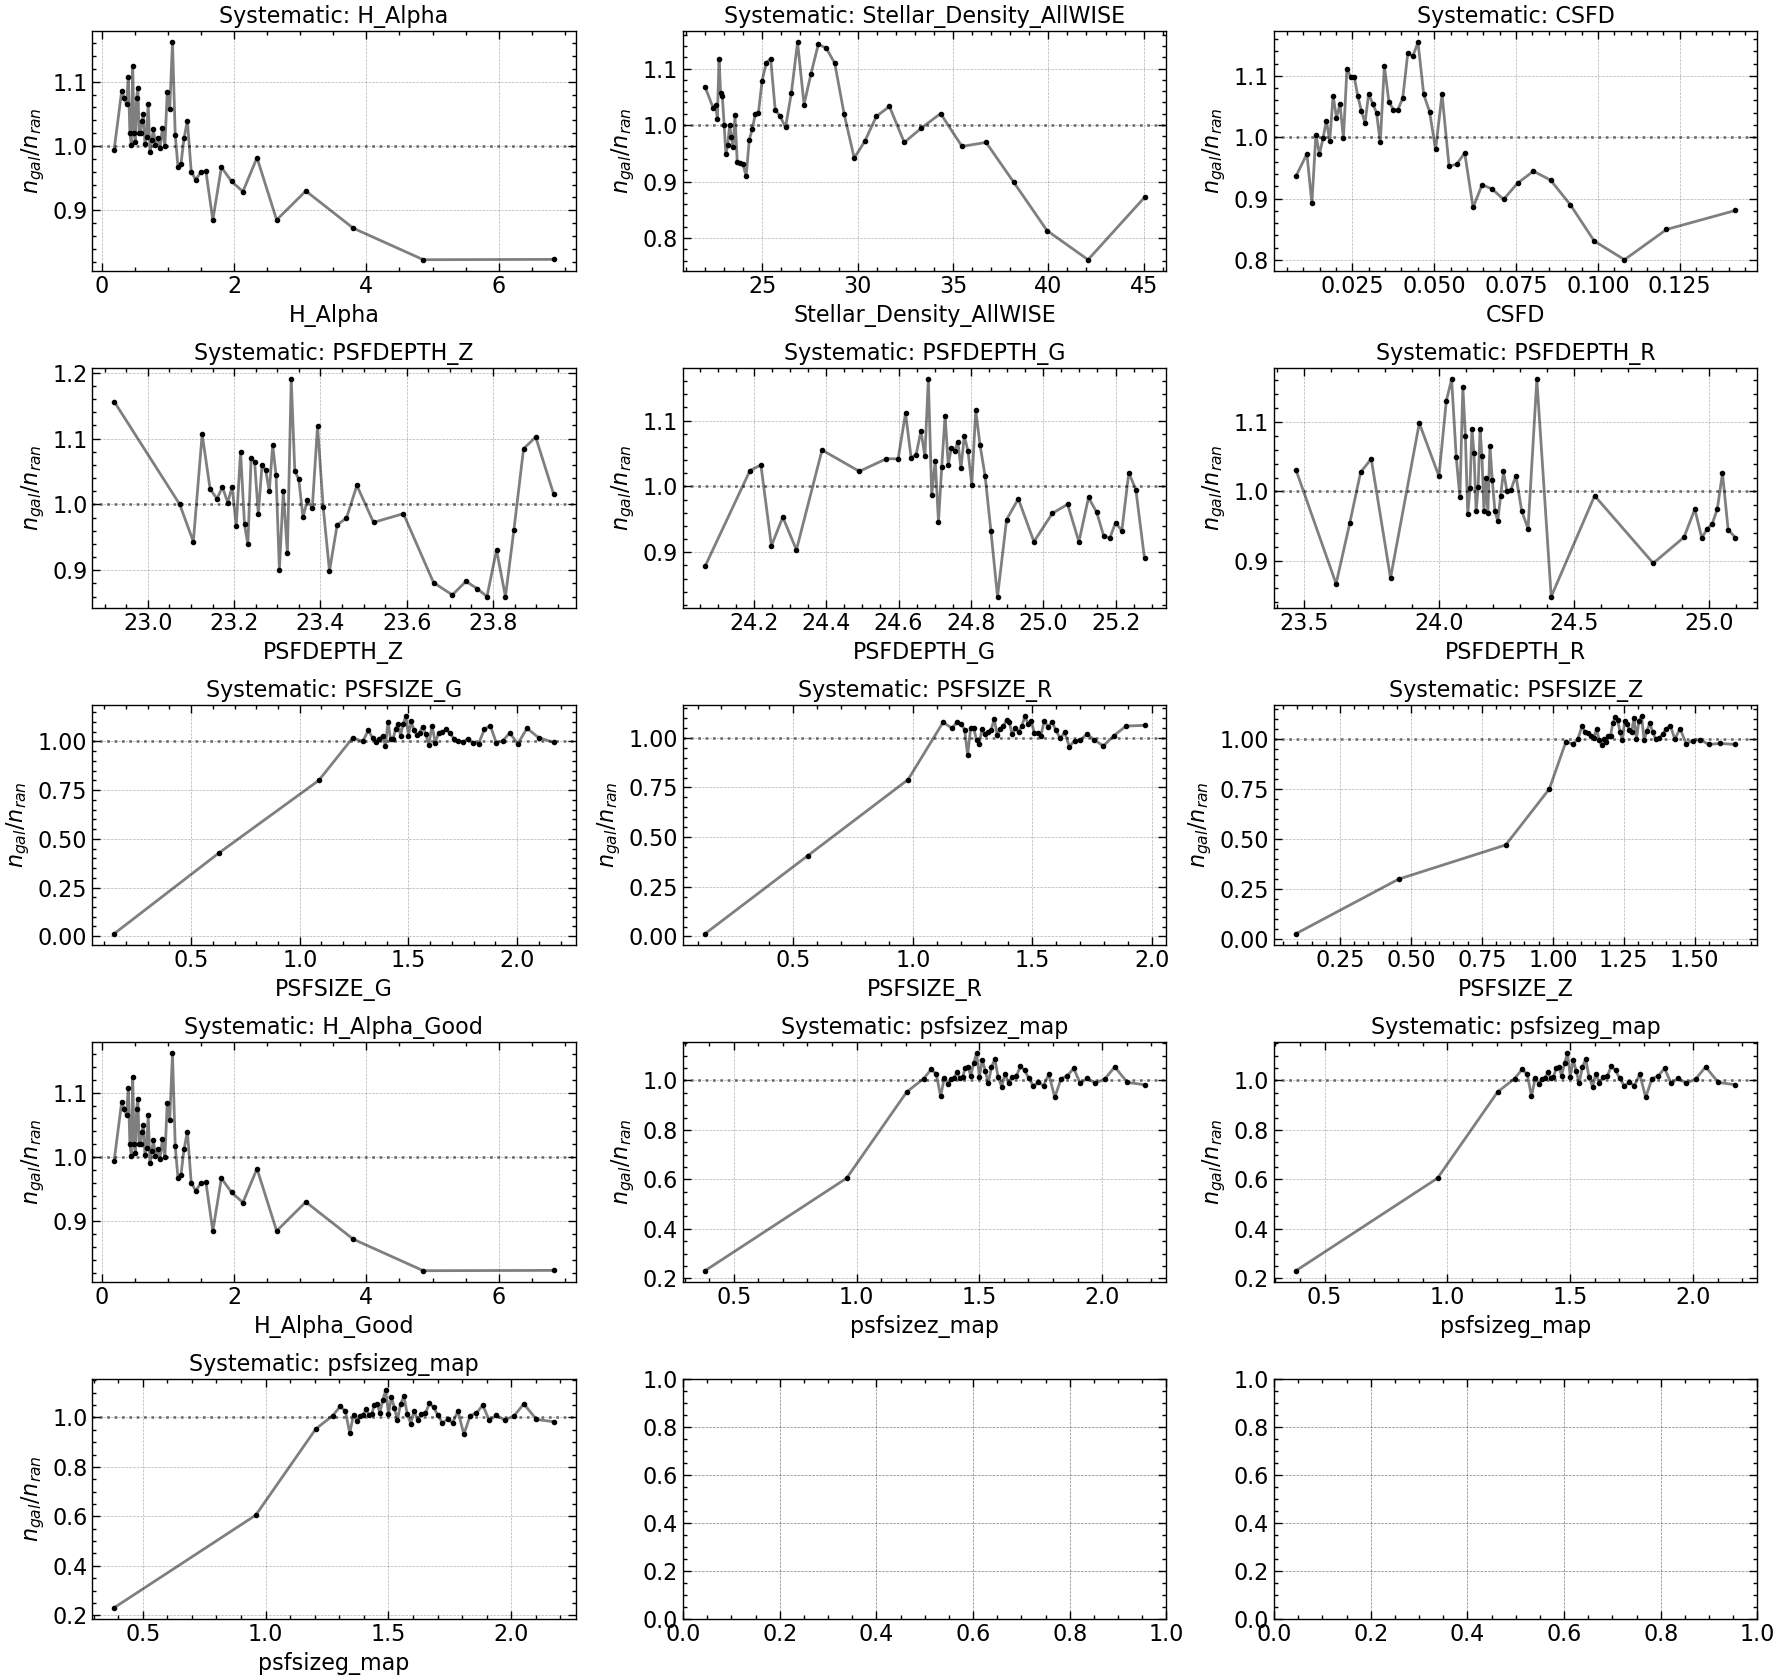

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(18, 17))
axes = axes.flatten()

for idx, sys_name in enumerate(systematics_list):
    plot_systematic_relation(ngal, nran, systematics_maps[sys_name][mask==1], ax=axes[idx])
    axes[idx].set_title(f'Systematic: {sys_name}')
    axes[idx].set_xlabel(sys_name)
    axes[idx].set_ylabel('$n_{gal} / n_{ran}$')



plt.tight_layout()
plt.show()


In [413]:
psfsizez_map = np.where((mask == 1) & (systematics_maps['PSFSIZE_Z'] == 0), np.nan, systematics_maps['PSFSIZE_Z'])
psfsizeg_map = np.where((mask == 1) & (systematics_maps['PSFSIZE_G'] == 0), np.nan, systematics_maps['PSFSIZE_G'])
psfsizer_map = np.where((mask == 1) & (systematics_maps['PSFSIZE_R'] == 0), np.nan, systematics_maps['PSFSIZE_R'])
mask_size_z = (mask == 1) & (systematics_maps['PSFSIZE_Z'] >1)
mask_size_g = (mask == 1) & (systematics_maps['PSFSIZE_G'] > 1)
mask_size_r =  (mask == 1) & (systematics_maps['PSFSIZE_G'] > 1)

(array([1.10765618, 1.24361825, 1.28696444, 1.31203021, 1.33082542,
        1.34720971, 1.36230842, 1.37588416, 1.38846098, 1.39994936,
        1.41082048, 1.42191448, 1.43279666, 1.44338411, 1.45412532,
        1.46522296, 1.47683197, 1.48830657, 1.49946169, 1.51105571,
        1.52262219, 1.53426162, 1.54679213, 1.56006364, 1.57341363,
        1.58679789, 1.60030771, 1.61433491, 1.62893024, 1.64401545,
        1.65964505, 1.67639085, 1.69325888, 1.71035494, 1.72953934,
        1.74946585, 1.77005228, 1.79214183, 1.81570573, 1.84079809,
        1.86616433, 1.89104713, 1.91755626, 1.94550228, 1.977349  ,
        2.01418929, 2.05579115, 2.10720506, 2.17616144, 2.42502509]),
 array([0.80225453, 0.98379318, 0.98393158, 1.01492006, 1.0066059 ,
        0.9583822 , 0.99732805, 0.96517739, 0.98675804, 1.02660624,
        1.00732341, 0.99158544, 0.99944646, 1.05309386, 1.03296793,
        1.01803552, 1.05419616, 1.09650361, 1.01538049, 1.0619929 ,
        1.02223762, 0.99420295, 1.02671464, 1.

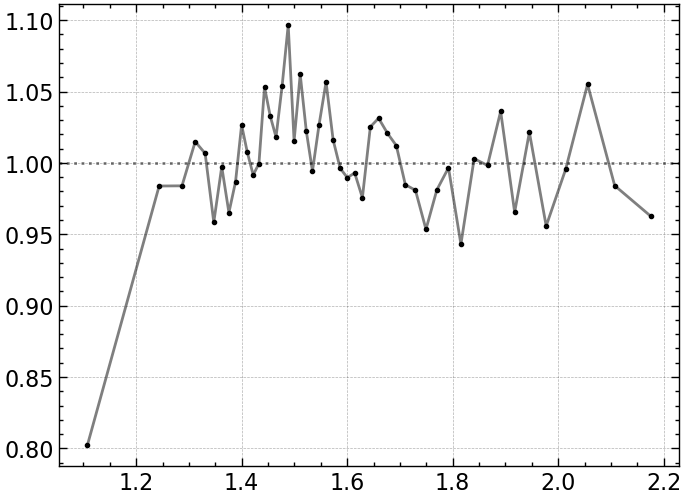

In [414]:
ngal_new = data_counts_subtracted[mask_size_g==1]
nran_new = randoms_counts_subtracted[mask_size_g==1]

plot_systematic_relation(ngal_new,nran_new,systematics_maps['PSFSIZE_G'][mask_size_g==1])


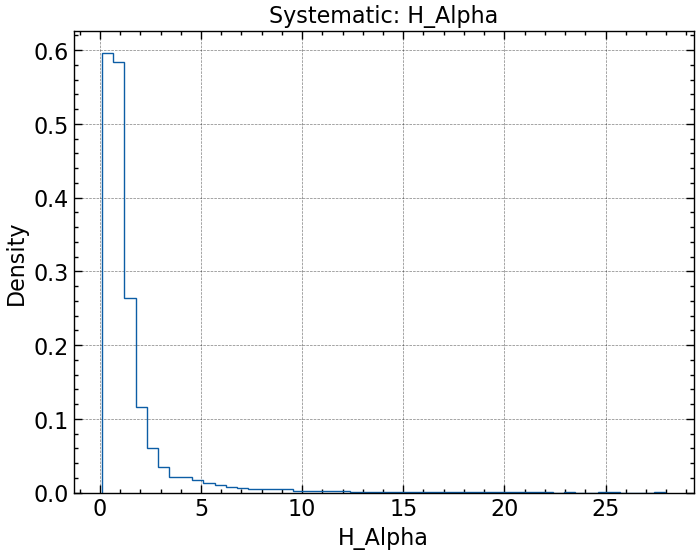

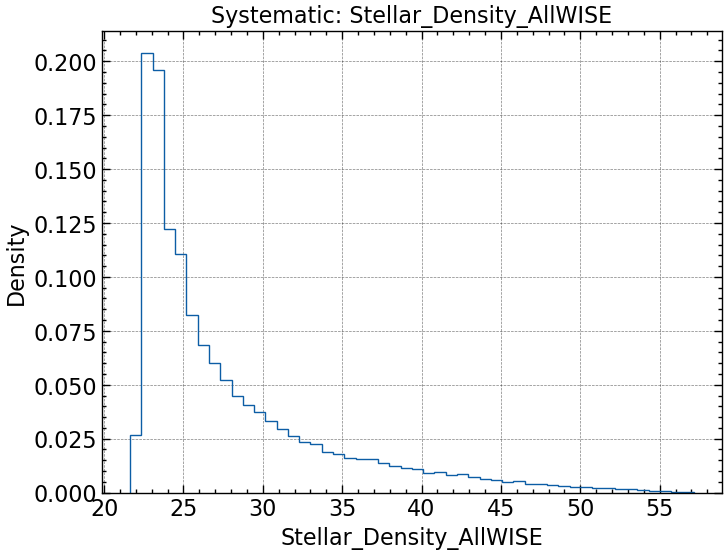

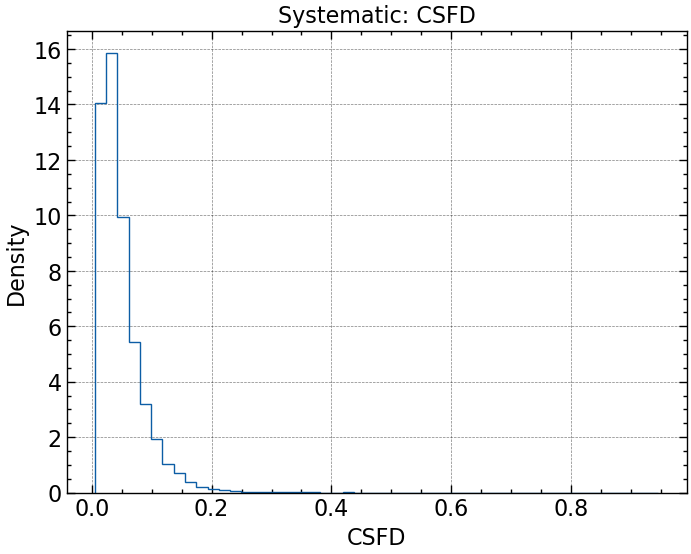

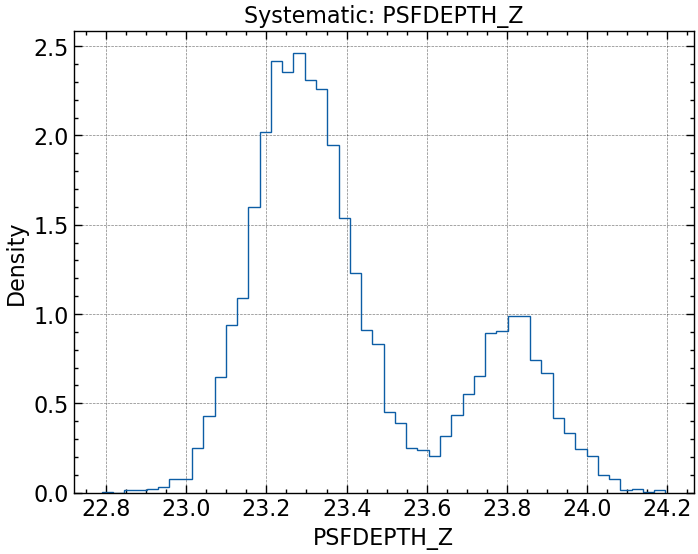

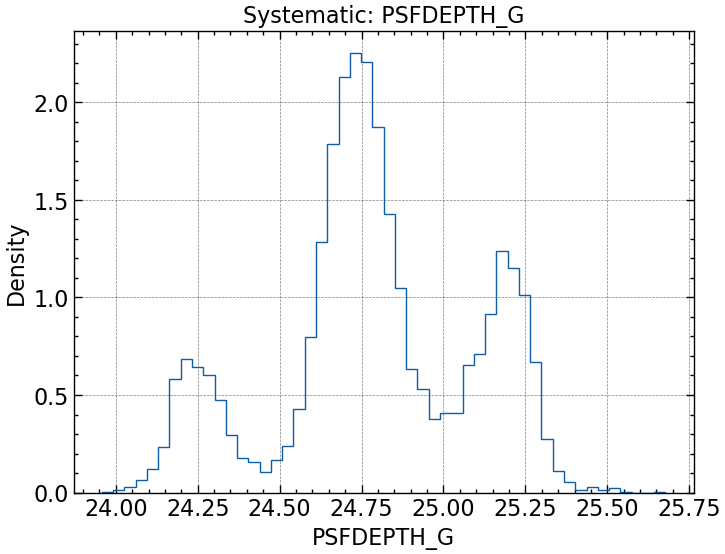

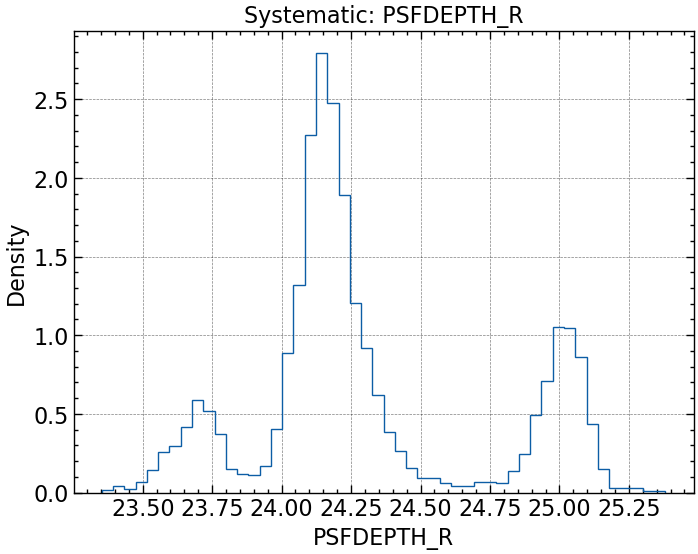

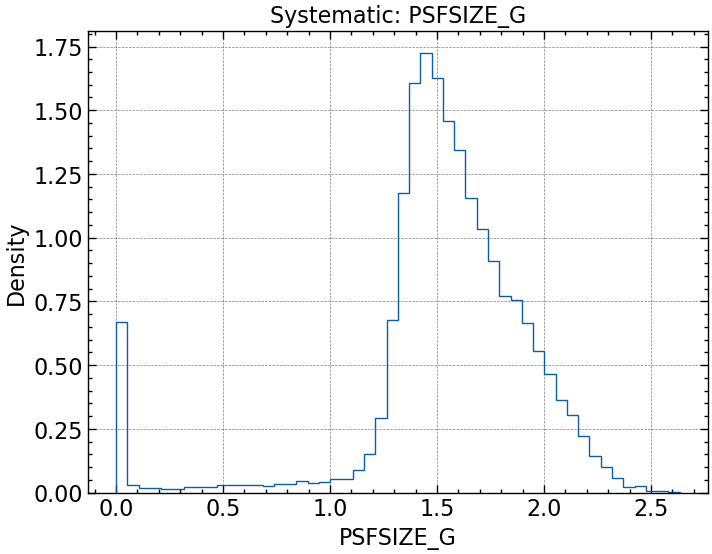

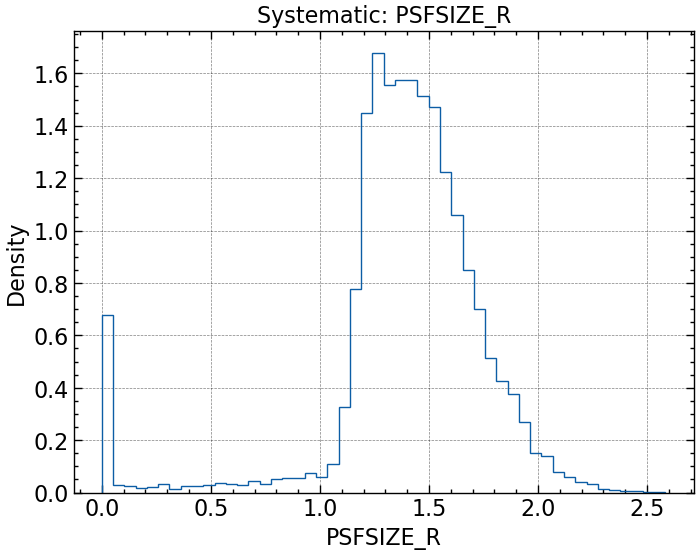

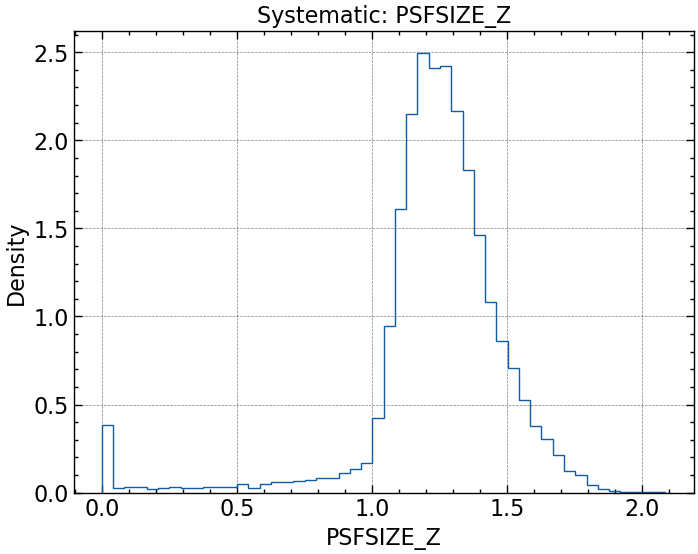

In [297]:

for idx, sys_name in enumerate(systematics_list):
    plt.hist(systematics_maps[sys_name][mask==1], bins=50, histtype='step', density=True)
    plt.title(f'Systematic: {sys_name}')
    plt.xlabel(sys_name)
    plt.ylabel('Density')
    plt.show()




In [252]:
X = df_full[['PSFDEPTH_Z',
 'PSFDEPTH_G',
 'PSFDEPTH_R',
 'PSFSIZE_G',
 'PSFSIZE_R',
 'PSFSIZE_Z',
 'CSFD_EBV',
 'STELLAR_DENSITY_ALLWISE',
 'H_ALPHA']][df_full['mask']==1].to_pandas().to_numpy()

X = df_full[[
 'CSFD_EBV',

]][df_full['mask']==1].to_pandas().to_numpy()
Y = df_full[['map']][df_full['mask']==1].to_pandas().to_numpy()

In [253]:
X_clean = X.copy()
X_clean[np.isinf(X_clean)] = np.nan

# Impute nan values with median (or mean)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_clean)

# Now apply StandardScaler
scaler = StandardScaler()
Xn = scaler.fit_transform(X_imputed)

In [255]:
reg = LinearRegression().fit(Xn, Y)
y_pred = reg.predict(Xn)

In [256]:
# y_pred is already in the original scale since Y was not transformed
# No inverse transformation needed
y_pred_original = y_pred
print("y_pred range:", y_pred_original.min(), "to", y_pred_original.max())
print("Y range:", Y.min(), "to", Y.max())

y_pred range: -2.2496481793063867 to 0.10906254297806862
Y range: -1.0 to 10.45638973915358


In [257]:
delta_sys = y_pred
print(delta_sys.min(), delta_sys.max(), delta_sys.std())

-2.2496481793063867 0.10906254297806862 0.09616572899738736


In [47]:
reg.coef_[0]

array([-0.09616573])

In [38]:
for name, coef in zip(cols, reg.coef_[0]):
    print(name, coef)

PSFDEPTH_Z 0.041106885914928004
PSFDEPTH_G 0.09526536323597547
PSFDEPTH_R -0.04499109353421261
PSFSIZE_G 0.10623337275919359
PSFSIZE_R 0.053712555346345045
PSFSIZE_Z 0.06741823533671976
CSFD_EBV -0.05235684213097314
STELLAR_DENSITY_ALLWISE -0.01130153013637303
H_ALPHA -0.01639289030769658


In [ ]:
# Recreate the plot of mean galaxy density / mean random density vs features
fig, axs = plt.subplots(6, 3, figsize=(12, 18))

# Define feature groups and labels
feature_groups = [
    ['CSFD_EBV', 'STELLAR_DENSITY_ALLWISE', 'H_ALPHA'],
    ['PSFDEPTH_R', 'PSFDEPTH_G', 'PSFDEPTH_Z'],
    ['PSFSIZE_R', 'PSFSIZE_G', 'PSFSIZE_Z']
]

x_labels = [
    ['E(B-V) [mag]', 'nstar [deg$^{-2}$]', 'H$\\alpha$'],
    ['Depth-r [mag]', 'Depth-g [mag]', 'Depth-z [mag]'],
    ['Seeing-r [arcsec]', 'Seeing-g [arcsec]', 'Seeing-z [arcsec]']
]

# Create bins for each feature
num_bins = 50

for i, feature_group in enumerate(feature_groups):
    for j, feature in enumerate(feature_group):
        ax = axs[i, j]
        
        # Get feature data for masked pixels
        features = df_full[feature][df_full['mask'] == 1]
        data = df_full['counts'][df_full['mask'] == 1]
        randoms = df_full['counts_randoms'][df_full['mask'] == 1]
        
        # Create bins
        bin_edges = np.linspace(np.nanmin(features), np.nanmax(features), num_bins + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # Compute mean galaxy density / mean random density in each bin
        normed_vals = np.zeros(num_bins)
        for k in range(num_bins):
            mask = (features >= bin_edges[k]) & (features < bin_edges[k+1])
            if np.sum(mask) > 0:
                mean_gal = np.mean(data[mask])
                mean_ran = np.mean(randoms[mask])
                if mean_ran > 0:
                    normed_vals[k] = mean_gal / mean_ran
                else:
                    normed_vals[k] = np.nan
        
        # Plot
        ax.plot(bin_centers, normed_vals, 'o-', markersize=3)
        ax.axhline(y=1, color='k', linestyle='--', alpha=0.5)
        ax.set_xlabel(x_labels[i][j])
        if j == 0:
            ax.set_ylabel('$\\bar n / \\bar n_{ran}$')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.show()

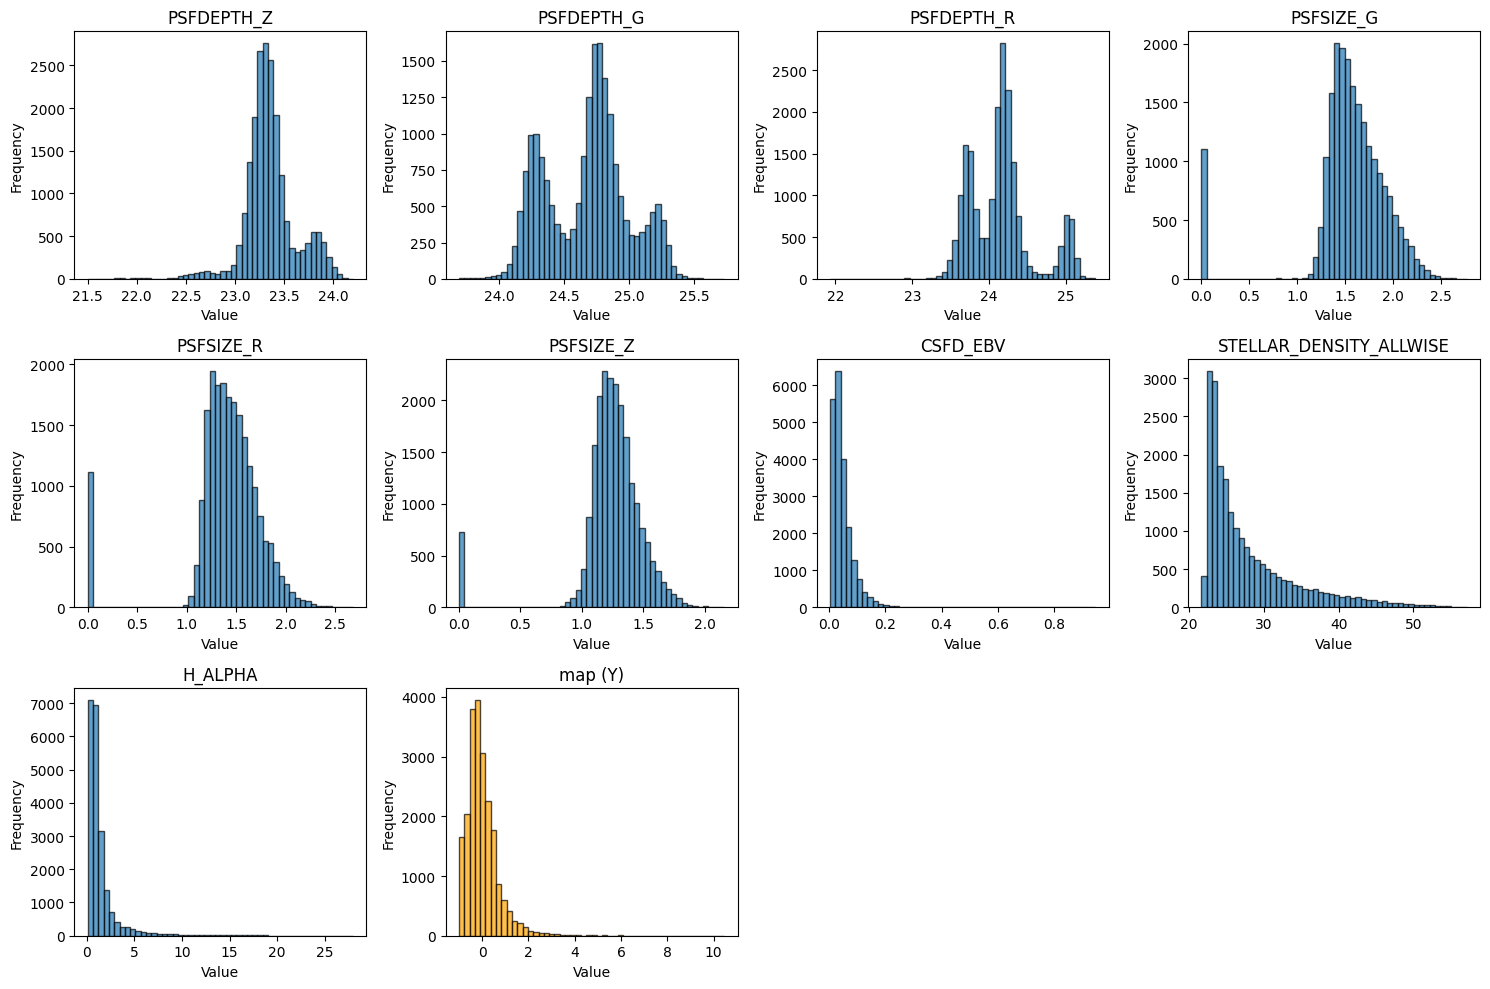

In [22]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

# Feature names
feature_names = ['PSFDEPTH_Z', 'PSFDEPTH_G', 'PSFDEPTH_R', 'PSFSIZE_G', 
                 'PSFSIZE_R', 'PSFSIZE_Z', 'CSFD_EBV', 'STELLAR_DENSITY_ALLWISE', 'H_ALPHA']

# Plot histogram for each feature in X
for i, feature_name in enumerate(feature_names):
    axes[i].hist(X[:, i][~np.isinf(X[:, i])], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(feature_name)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Plot histogram for Y
axes[9].hist(Y, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[9].set_title('map (Y)')
axes[9].set_xlabel('Value')
axes[9].set_ylabel('Frequency')

# Hide unused subplots
for i in range(10, 12):
    axes[i].axis('off')

plt.tight_layout()
plt.show()